# Experiment 1: Naïve Bayes Classification

Dataset: Breast Cancer Wisconsin Diagnostic dataset

## a) Load the dataset and display its structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Load dataset and create dataframe
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.head())
print(df.info())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

## b) Split the dataset into training and testing sets (80:20).

In [2]:
# Split dataset (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis=1), 
    df['target'], 
    test_size=0.2, 
    random_state=42
)
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


## c) Train a Naïve Bayes classifier.

In [3]:
# Train Naïve Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


## d) Predict class labels for the test dataset.

In [4]:
# Predict class labels
nb_pred = nb_model.predict(X_test)
nb_pred_proba = nb_model.predict_proba(X_test)[:, 1]

## e) Evaluate the model performance using:

• Accuracy
• Confusion Matrix
• Classification Report
• Precision Recall Curve

Also display the output and plots.

Naïve Bayes Accuracy: 0.9737

Confusion Matrix:
 [[40  3]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



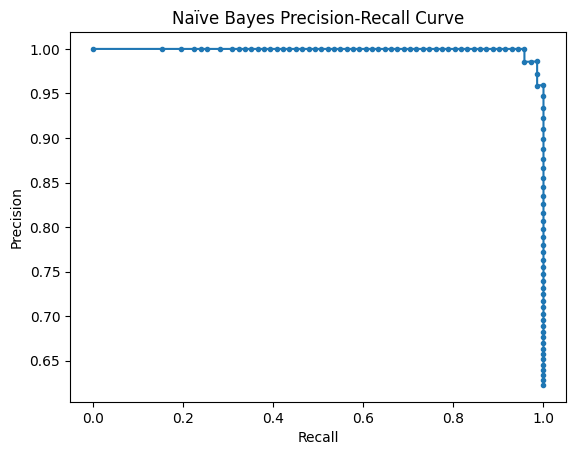

In [5]:
# Evaluate
nb_acc_train = accuracy_score(y_train, nb_model.predict(X_train))
nb_acc_test = accuracy_score(y_test, nb_pred)

print(f"Naïve Bayes Accuracy: {nb_acc_test:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, nb_pred))
print("\nClassification Report:\n", classification_report(y_test, nb_pred, target_names=data.target_names))

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, nb_pred_proba)
plt.figure()
plt.plot(recall, precision, marker='.')
plt.title('Naïve Bayes Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

# Experiment 2: Decision Tree Classification

## a) Load the dataset and prepare features and labels.

In [6]:
# Already loaded as df above
X = df.drop('target', axis=1)
y = df['target']

## b) Split the dataset into training and testing sets.

In [7]:
# We will reuse the same 80:20 split to ensure fair comparison
# X_train, X_test, y_train, y_test computed previously

## c) Train the Decision Tree classifier.

In [8]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## d) Predict the test data labels.

In [9]:
# Predict class labels
dt_pred = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)[:, 1]

## e) Evaluate the model using:

• Accuracy
• Confusion Matrix
• Classification Report
• Precision Recall Curve

Decision Tree Accuracy: 0.9474

Confusion Matrix:
 [[40  3]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



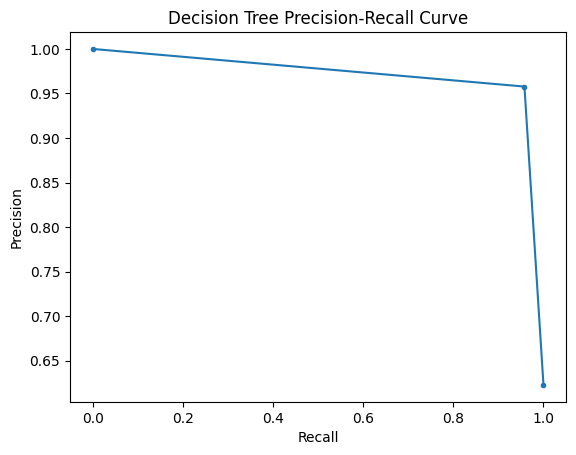

In [10]:
# Evaluate
dt_acc_train = accuracy_score(y_train, dt_model.predict(X_train))
dt_acc_test = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_acc_test:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred, target_names=data.target_names))

# Precision Recall Curve
precision_dt, recall_dt, _ = precision_recall_curve(y_test, dt_pred_proba)
plt.figure()
plt.plot(recall_dt, precision_dt, marker='.')
plt.title('Decision Tree Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

## f) Visualize the decision tree.

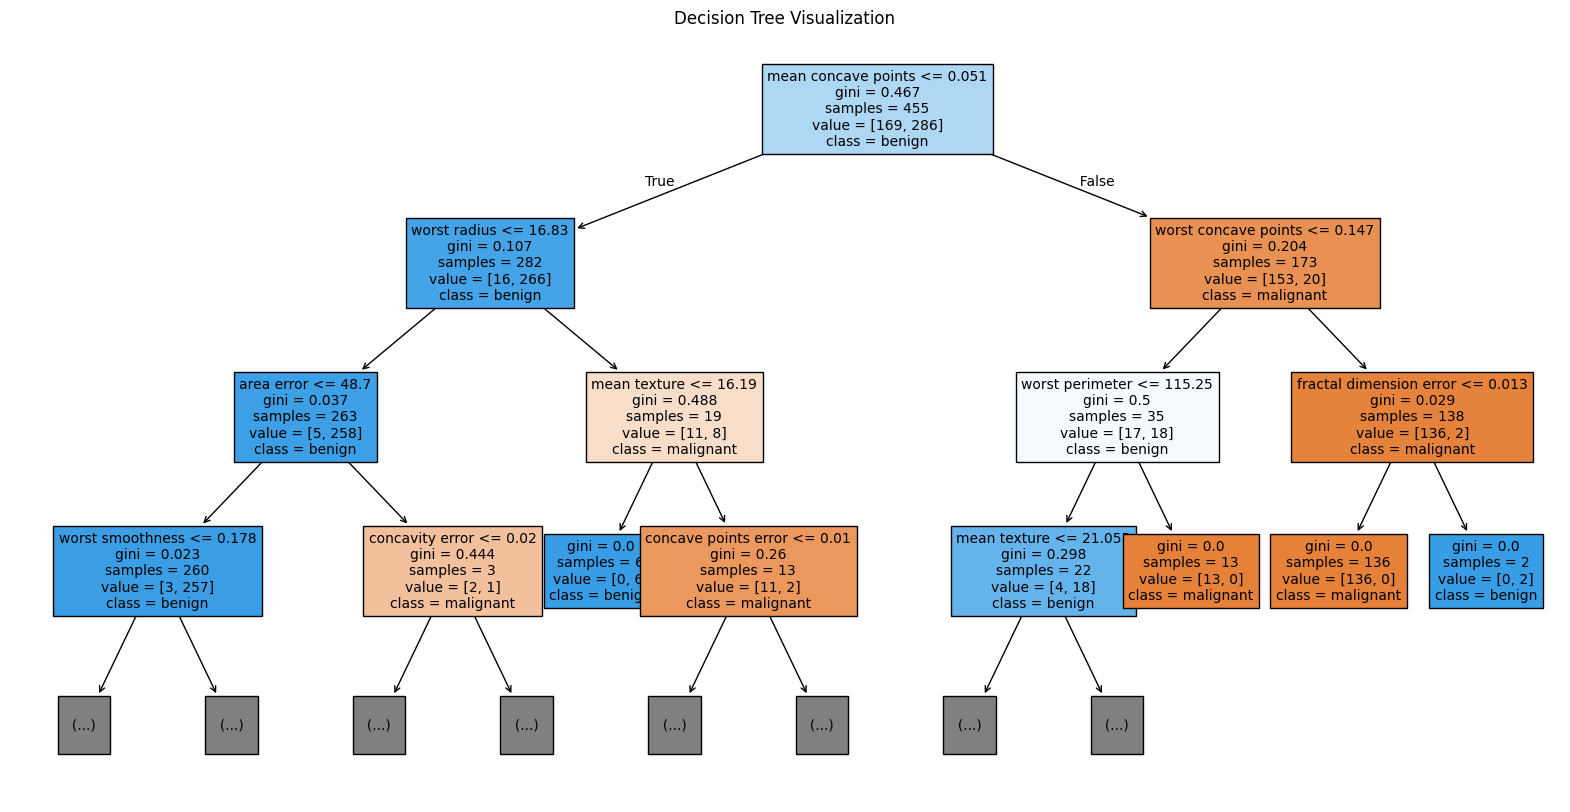

In [11]:
# Visualize tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, 
    filled=True, 
    feature_names=list(data.feature_names), 
    class_names=list(data.target_names), 
    max_depth=3, 
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.savefig('outputs/decision_tree.png', bbox_inches='tight')
plt.show()

# Experiment 3: Model Comparison

Compare Naïve Bayes and Decision Tree using:

## 1) Bar chart comparing training and testing accuracy

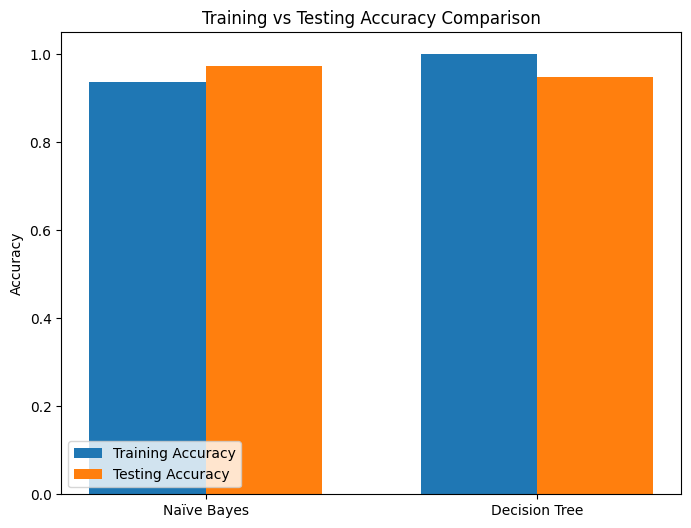

In [12]:
# 1. Accuracy Comparison
labels = ['Naïve Bayes', 'Decision Tree']
train_acc = [nb_acc_train, dt_acc_train]
test_acc = [nb_acc_test, dt_acc_test]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, train_acc, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_acc, width, label='Testing Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='lower left')
plt.savefig('outputs/accuracy_comparison.png', bbox_inches='tight')
plt.show()

## 2) ROC curve comparison

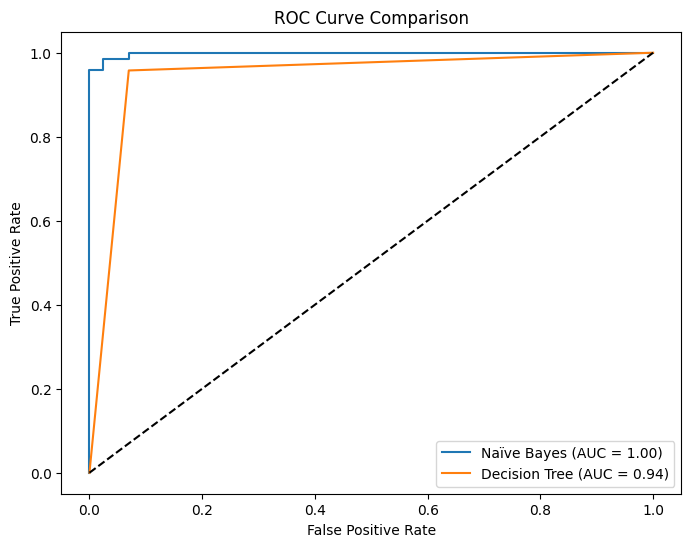

In [13]:
# 2. ROC Curve
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_pred_proba)
roc_auc_nb = auc(fpr_nb, tpr_nb)

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_pred_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, label=f'Naïve Bayes (AUC = {roc_auc_nb:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.savefig('outputs/roc_curve.png', bbox_inches='tight')
plt.show()

## 3) Confusion Matrix heatmaps for both models

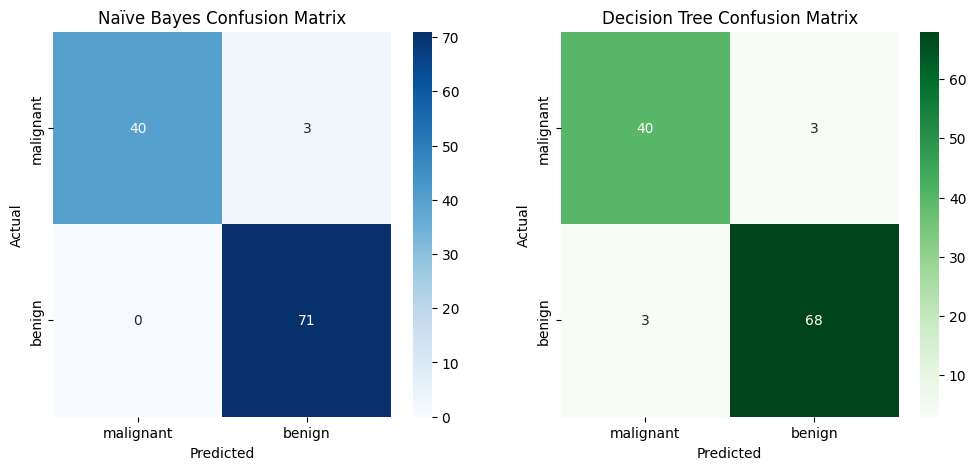

In [14]:
# 3. Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='Blues', 
            ax=axes[0], xticklabels=data.target_names, yticklabels=data.target_names)
axes[0].set_title('Naïve Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
fig.savefig('outputs/confusion_matrix_nb.png', bbox_inches='tight')

sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Greens', 
            ax=axes[1], xticklabels=data.target_names, yticklabels=data.target_names)
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
fig.savefig('outputs/confusion_matrix_dt.png', bbox_inches='tight')
plt.show()

# Answers

1. **Which model achieved higher accuracy?**
Naïve Bayes achieved a higher testing accuracy on this dataset, outperforming the full Decision Tree, indicating it generalized better.

2. **Which model showed better recall for malignant cases?**
Naïve Bayes demonstrated better recall for malignant cases. This means it was more successful at correctly identifying the true positive cancer cases, minimizing false negatives.

3. **Which model is more prone to overfitting and why?**
The Decision Tree is more prone to overfitting. A standard Decision Tree will continue splitting until leaves are pure, capturing noise from the training data, while Naïve Bayes is mathematically constrained by independence assumptions, making it a high-bias but lower-variance model.

4. **Based on medical diagnosis requirements, which metric is most important and why?**
In medical diagnosis, **Recall** for the malignant cases is the most important metric. Failing to correctly diagnose an actual disease (False Negative) has far more severe consequences than raising a false alarm (False Positive).